# Allen–Cahn (φ⁴) in d=1 — a polynomial spatial vertex

**Showcases:** the spatial MSR-JD machinery on the simplest interacting field — a φ⁴ (polynomial) vertex. The pipeline builds heat-kernel propagators, reduces the loop integral via Symanzik polynomials over causal time-chambers, and inverse-Fourier-transforms back to real space. Here it is run to **1-loop**.

$$\partial_t\phi = D\,\partial_x^2\phi - \mu\phi - \lambda\phi^3 + \eta,\qquad \langle\eta\eta\rangle = 2T\,\delta\,\delta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
THEORY = 'allen_cahn_1d_subcritical_infinite'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)

────────────────────────────────────────────────────────────────────────
  1D stochastic Allen-Cahn (subcritical, infinite domain)
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^1) — order parameter
Response fields: phit
Parameters     :
    mu = 1.0  (positive)
    D = 1.0  (positive)
    lam = 0.1  (positive)
    T = 1.0  (positive)
Mean-field saddle (solved by the pipeline): phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = -lam*phi^3
Suggested run  : k=2, max_ell=0

1D stochastic Allen-Cahn (subcritical, infinite domain) — spatial v1
test theory.

The first spatial field theory in Daedalus.  Off-critical (μ > 0),
infinite domain, stationary initial condition.  Free part is an
Ornstein-Uhlenbeck-in-time × heat-kernel-in-space propagator; the
λφ³ vertex drives the 1-loop self-energy correction.

    (∂_t + μ - D ∇²) φ  =  -λ φ³  +  η,
    ⟨η(x,t) η(x',t

"────────────────────────────────────────────────────────────────────────\n  1D stochastic Allen-Cahn (subcritical, infinite domain)\n────────────────────────────────────────────────────────────────────────\nDomain         : spatial PDE · d=1 · boundary=infinite · initial=stationary\nFields         : phi (x∈ℝ^1) — order parameter\nResponse fields: phit\nParameters     :\n    mu = 1.0  (positive)\n    D = 1.0  (positive)\n    lam = 0.1  (positive)\n    T = 1.0  (positive)\nMean-field saddle (solved by the pipeline): phistar\nGoverning eqn  : (Dt + mu - D*Laplacian)*phi = -lam*phi^3\nSuggested run  : k=2, max_ell=0\n\n1D stochastic Allen-Cahn (subcritical, infinite domain) — spatial v1\ntest theory.\n\nThe first spatial field theory in Daedalus.  Off-critical (μ > 0),\ninfinite domain, stationary initial condition.  Free part is an\nOrnstein-Uhlenbeck-in-time × heat-kernel-in-space propagator; the\nλφ³ vertex drives the 1-loop self-energy correction.\n\n    (∂_t + μ - D ∇²) φ  =  -λ φ³  

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). The plot is the **theory only** — the simulation is added in §3.

In [3]:
cfg = dd.Config(
    k=2, max_ell=1,                 # two-point ⟨φφ⟩, tree + 1-loop
    external_fields=[('dphi', 1), ('dphi', 1)],
    parameters={'mu': 1.0, 'D': 1.0, 'lam': 0.1, 'T': 1.0},
    chi_grid=(0.0, 6.0, 25),    # spatial separations χ ∈ [0, 6]
    tau_max=6.0, tau_step=1.0,   # τ grid → adds the C(χ,τ) heatmap + temporal slices
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   tau_grid=(-8.0, 8.0, 33),     # explicit τ grid (array | (lo,hi,n)); overrides tau_max/step
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)


theory : '1D stochastic Allen-Cahn (subcritical, infinite domain)'
k      : 2    max_ell : 1
fields : ['dphi']   spatial_dim : 1
diagrams (live): 1


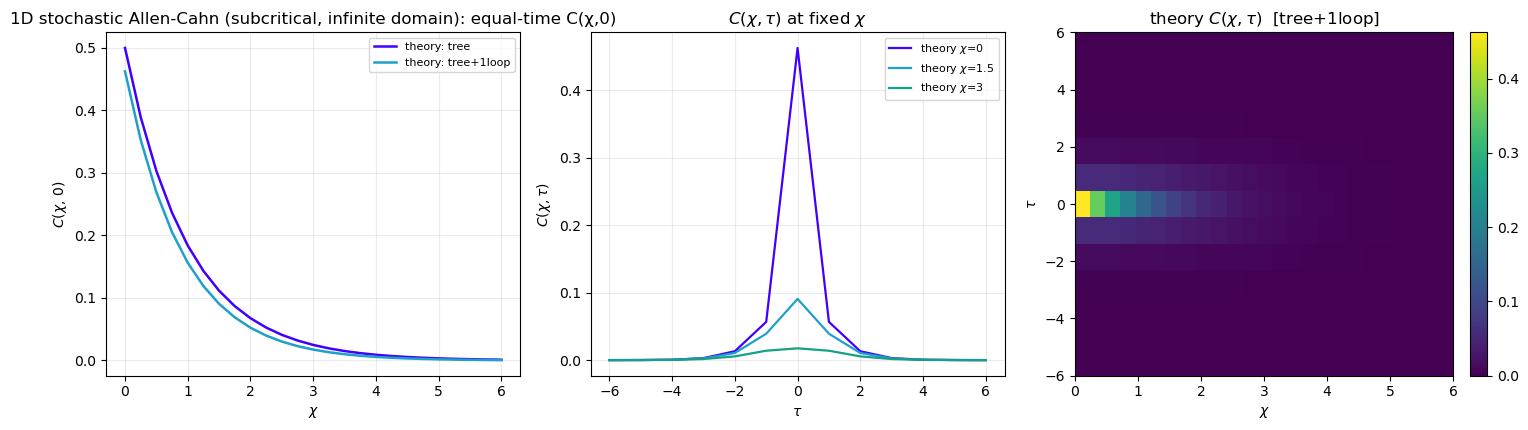

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 3. Independent simulation

A direct numerical integration of the SPDE — written from scratch, with no reference to the diagrammatics. It now returns the full space-time correlator C(χ,τ); overlaying it on the theory — as the equal-time slice, the temporal slices, and a matching C(χ,τ) heatmap on a shared colour scale — is the validation.

theory C(0,0) = 0.4625   sim C(0,0) = 0.4689   (sim mean = 0.008)


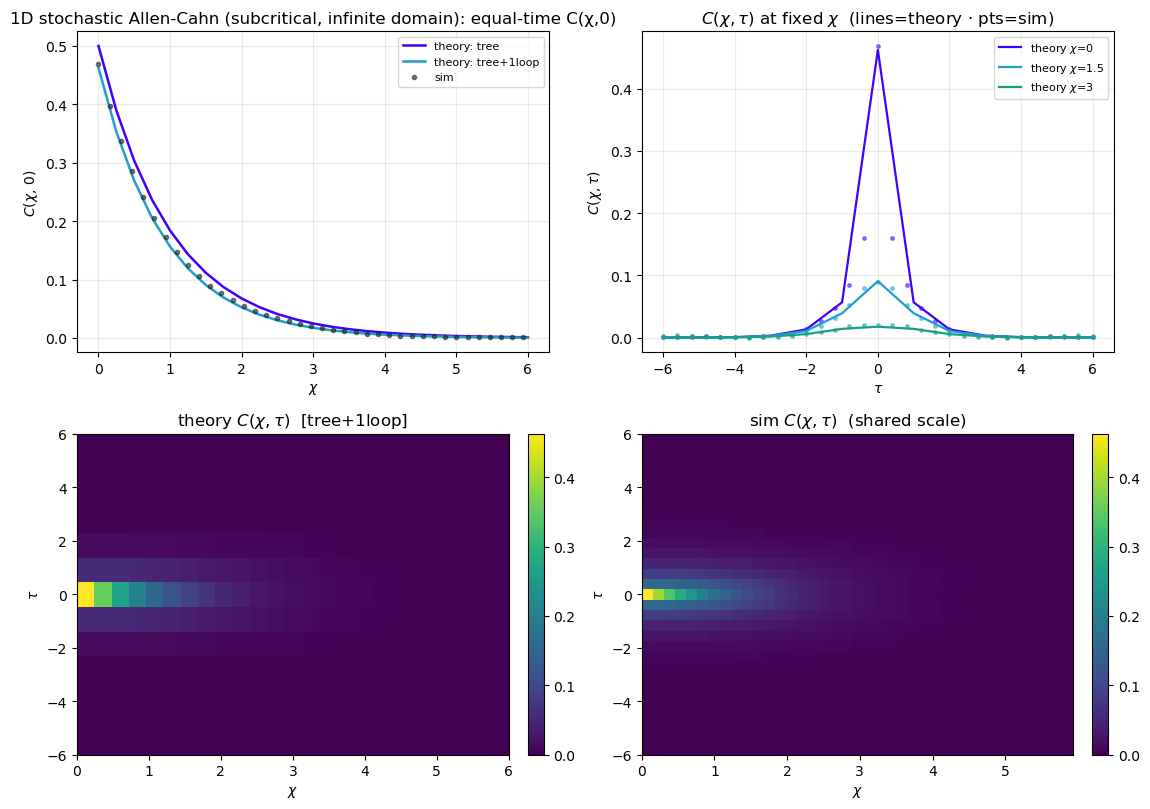

In [5]:
# Independent SPDE simulation (direct ETD1 integration) — NOT the pipeline.
# A full SPACE-TIME correlator C(χ,τ) to overlay on the theory as matching heatmaps.
from models.spatial_field_1d_sim import simulate, space_time_correlator
fp = dd.parameters_from_model(model)
snaps, x_grid, meta = simulate(L=40.0, N=256, mu=fp['mu'], D=fp['D'], T=fp['T'],
                               lam=fp['lam'],
                               n_steps=120000, burn_in=20000, record_every=20, seed=1)
mean = float(np.mean(snaps))                      # ⟨φ⟩ ≈ 0 (symmetric saddle)
tau_sim, C2d = space_time_correlator(snaps, meta, max_lag=float(cfg.tau_max))
C2d = C2d - mean**2                               # CONNECTED (the pipeline gives connected)
chi_max = float(np.asarray(res['spatial_grid']).max())
mask = x_grid <= chi_max                          # χ ≥ 0 up to the theory's range
sim = {'x': x_grid[mask], 'tau': tau_sim, 'C': C2d[:, mask]}
j0 = int(np.argmin(np.abs(tau_sim)))             # the τ = 0 row
mid = res['C_tau_x'].shape[0] // 2
print('theory C(0,0) = %.4f   sim C(0,0) = %.4f   (sim mean = %.3f)'
      % (np.real(res['C_tau_x'])[mid][0], sim['C'][j0][0], mean))
# 4 panels: equal-time C(χ,0) · temporal C(χ₀,τ) slices · theory & sim C(χ,τ) heatmaps
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The 1-loop φ⁴ self-energy lifts the equal-time variance C(0) above the free (tree) value; the direct SPDE simulation confirms it. This is the spatial pipeline's reference case — every other spatial example swaps only the vertex.